In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Установка и импорт библиотек
!pip install folium -q
import pandas as pd
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/data_sets/dtp201804.csv',
                 encoding="utf-8",
                 delimiter=";",
                 on_bad_lines='skip')

print(f"✅ Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Предобработка данных
df['crash_date'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')
df['crash_time'] = pd.to_datetime(df['crash_time'], format='%H:%M:%S', errors='coerce').dt.time
df['datetime'] = pd.to_datetime(df['crash_date'].astype(str) + ' ' + df['crash_time'].astype(str))

# Удаляем строки с отсутствующими координатами
df_clean = df.dropna(subset=['latitude', 'longitude']).copy()
print(f"✅ Данные после очистки: {df_clean.shape[0]} строк")

✅ Данные загружены: 39086 строк, 17 столбцов
✅ Данные после очистки: 39086 строк


In [ ]:
# ВСЕ ВМЕСТЕ ДЛЯ КОПИРОВАНИЯ:

!pip install folium -q
import pandas as pd
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')


# 2. Анализ регионов
regions_stats = df_clean.groupby(['reg_code', 'reg_name']).agg({
    'latitude': 'count', 'fatalities_amount': 'sum', 'victims_amount': 'sum'
}).rename(columns={'latitude': 'accidents_count'}).reset_index()
top_regions = regions_stats.sort_values('accidents_count', ascending=False).head(10)

# 3. Создание карты
center_lat, center_lon = df_clean['latitude'].mean(), df_clean['longitude'].mean()
heat_map = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles='CartoDB positron')

# 4. Данные для тепловой карты
heat_data = [[row['latitude'], row['longitude'], 1] for _, row in df_clean.iterrows()]

# 5. Тепловой слой
HeatMap(heat_data, radius=15, blur=20, max_zoom=10, min_opacity=0.4).add_to(heat_map)

# 6. Маркеры для топ-5 регионов
colors = ['red', 'darkred', 'orange', 'purple', 'darkblue']
for i, (_, region) in enumerate(top_regions.head(5).iterrows()):
    region_data = df_clean[df_clean['reg_name'] == region['reg_name']]
    if len(region_data) > 0:
        avg_lat, avg_lon = region_data['latitude'].mean(), region_data['longitude'].mean()
        folium.CircleMarker(
            location=[avg_lat, avg_lon],
            radius=15 + i*3,
            popup=f"<b>{region['reg_name']}</b><br>ДТП: {region['accidents_count']:,}<br>Погибших: {region['fatalities_amount']:,}",
            color=colors[i], fill=True, fill_opacity=0.7
        ).add_to(heat_map)

# 7. Заголовок
title_html = '<h3 align="center">Тепловая карта ДТП в России (Апрель 2018)</h3>'
heat_map.get_root().html.add_child(folium.Element(title_html))

# 8. Вывод
heat_map.save('/content/drive/MyDrive/data_sets/heatmap_dtp.html')
print("✅ Тепловая карта создана и сохранена!")
heat_map



✅ Тепловая карта создана и сохранена!


In [ ]:
# Дополнительный анализ: таблица всех регионов
print("\n" + "="*80)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВСЕ РЕГИОНЫ")
print("="*80)

# Создаем подробную таблицу
detailed_stats = regions_stats.sort_values('accidents_count', ascending=False)
detailed_stats['percent_of_total'] = (detailed_stats['accidents_count'] / df_clean.shape[0] * 100).round(2)
detailed_stats['fatalities_per_accident'] = (detailed_stats['fatalities_amount'] / detailed_stats['accidents_count']).round(3)
detailed_stats['victims_per_accident'] = (detailed_stats['victims_amount'] / detailed_stats['accidents_count']).round(3)

# Переименовываем столбцы для удобства
detailed_stats = detailed_stats.rename(columns={
    'reg_name': 'Регион',
    'accidents_count': 'Кол-во ДТП',
    'fatalities_amount': 'Погибло',
    'victims_amount': 'Пострадало',
    'vehicles_amount': 'ТС участников',
    'percent_of_total': '% от всех ДТП',
    'fatalities_per_accident': 'Погибших/ДТП',
    'victims_per_accident': 'Пострадавших/ДТП'
})

# Выводим таблицу
print("Статистика по всем регионам (первые 15):")
display(detailed_stats.head(15).style
        .background_gradient(subset=['Кол-во ДТП'], cmap='Reds')
        .background_gradient(subset=['Погибло'], cmap='Oranges')
        .background_gradient(subset=['Пострадало'], cmap='YlOrBr')
        .format({
            'Кол-во ДТП': '{:,}',
            'Погибло': '{:,}',
            'Пострадало': '{:,}',
            'ТС участников': '{:,}',
            '% от всех ДТП': '{:.1f}%',
            'Погибших/ДТП': '{:.3f}',
            'Пострадавших/ДТП': '{:.3f}'
        }))

# Сохраняем статистику в CSV
stats_path = '/content/drive/MyDrive/data_sets/regions_dtp_statistics.csv'
detailed_stats.to_csv(stats_path, index=False, encoding='utf-8')
print(f"\n📊 Подробная статистика сохранена: {stats_path}")


ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВСЕ РЕГИОНЫ
Статистика по всем регионам (первые 15):


,reg_code,Регион,Кол-во ДТП,Погибло,Пострадало,% от всех ДТП,Погибших/ДТП,Пострадавших/ДТП
35,46,Московская область,"2,764","3,812",585,7.1%,1.379,0.212
1,3,Краснодарский край,"2,294","3,308",572,5.9%,1.442,0.249
31,41,Ленинградская область,"1,425","2,175",282,3.6%,1.526,0.198
61,80,Республика Башкортостан,"1,075","1,542",299,2.8%,1.434,0.278
4,7,Ставропольский край,956,"1,499",250,2.5%,1.568,0.262
45,60,Ростовская область,948,"1,391",306,2.4%,1.467,0.323
34,45,Москва,933,"1,218",88,2.4%,1.305,0.094
73,92,Республика Татарстан,876,"1,349",193,2.2%,1.540,0.220
11,17,Владимирская область,841,"1,291",148,2.1%,1.535,0.176
2,4,Красноярский край,803,"1,239",224,2.0%,1.543,0.279



📊 Подробная статистика сохранена: /content/drive/MyDrive/data_sets/regions_dtp_statistics.csv


***Задание 2***

In [ ]:
# 2. Фильтрация ДТП с жертвами (>10 погибших)
# Правильный импорт для MarkerCluster
from folium.plugins import MarkerCluster

# Теперь код должен работать
marker_cluster = MarkerCluster().add_to(fatal_map)
for _, row in fatal_accidents.iterrows():
    f = int(row['fatalities_amount'])
    # ... остальной код
fatal_accidents = df_clean[df_clean['fatalities_amount'] > 10].copy()
if len(fatal_accidents) == 0:
    fatal_accidents = df_clean[df_clean['fatalities_amount'] > 5].copy()

# 3. Создание карты
center_lat, center_lon = fatal_accidents[['latitude', 'longitude']].mean()
fatal_map = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles='CartoDB dark_matter')

# 4. Функция для цвета
def get_color(f):
    if f >= 20: return 'black'
    elif f >= 15: return 'darkred'
    elif f >= 10: return 'red'
    elif f >= 5: return 'orange'
    else: return 'yellow'

# 5. Добавление маркеров
marker_cluster = MarkerCluster().add_to(fatal_map)
for _, row in fatal_accidents.iterrows():
    f = int(row['fatalities_amount'])
    html = f'<div style="background:{get_color(f)};color:white;border-radius:50%;padding:5px;text-align:center;">{f}</div>'

    icon = folium.DivIcon(html=html, icon_size=(30,30))

    popup = f"""
    <b>Дата:</b> {row['crash_date'].strftime('%d.%m.%Y')}<br>
    <b>Регион:</b> {row['reg_name']}<br>
    <b>Тип:</b> {row['crash_type_name']}<br>
    <b>Причина:</b> {row['crash_reason']}<br>
    <b>Погибших:</b> {f}
    """

    folium.Marker(
        [row['latitude'], row['longitude']],
        icon=icon,
        popup=popup,
        tooltip=f"{row['reg_name']}: {f} погибших"
    ).add_to(marker_cluster)

# 6. Ответы на вопросы
if len(fatal_accidents) > 0:
    worst = fatal_accidents.loc[fatal_accidents['fatalities_amount'].idxmax()]
    print(f"Максимальное число смертельных случаев: {int(worst['fatalities_amount'])}")
    print(f"Область: {worst['reg_name']}")
    print(f"Дата: {worst['crash_date'].strftime('%d.%m.%Y')}")

# 7. Вывод карты
fatal_map.save('/content/drive/MyDrive/data_sets/fatal_dtp_map.html')
print("✅ Карта создана и сохранена!")
fatal_map

Максимальное число смертельных случаев: 46
Область: Псковская область
Дата: 22.05.2018
✅ Карта создана и сохранена!


In [ ]:
# Правильные импорты
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
import numpy as np
import pandas as pd
import plotly.express as px

***Задание 3***

In [ ]:
# 2. Фильтрация ДТП с жертвами
fatal_accidents = df_clean[df_clean['fatalities_amount'] > 5].copy()

# 3. Анализ типов
crash_types = fatal_accidents['crash_type_name'].unique()
n_types = len(crash_types)
cmap = cm.get_cmap('tab20c', n_types)
colors = [mcolors.to_hex(cmap(i)) for i in range(n_types)]
color_dict = {t: colors[i] for i, t in enumerate(crash_types)}

# 4. Создание карты
center_lat, center_lon = fatal_accidents[['latitude', 'longitude']].mean()
crash_type_map = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles='CartoDB dark_matter')

# 5. Добавление маркеров
for crash_type in crash_types:
    MarkerCluster(name=crash_type).add_to(crash_type_map)

for _, row in fatal_accidents.iterrows():
    crash_type = row['crash_type_name']
    f = int(row['fatalities_amount'])
    color = color_dict.get(crash_type, '#808080')

    html = f'<div style="background:{color};color:white;border-radius:50%;width:30px;height:30px;display:flex;align-items:center;justify-content:center;">{f}</div>'

    icon = folium.DivIcon(html=html, icon_size=(30,30))

    popup = f"""
    <b>Тип:</b> {crash_type}<br>
    <b>Причина:</b> {row['crash_reason']}<br>
    <b>Дата:</b> {row['crash_date'].strftime('%d.%m.%Y')}<br>
    <b>Погибших:</b> {f}
    """

    folium.Marker(
        [row['latitude'], row['longitude']],
        icon=icon,
        popup=popup,
        tooltip=f"{crash_type}: {f} погибших"
    ).add_to(crash_type_map)

# 6. Легенда
legend_html = '<div style="position:fixed;bottom:50px;right:50px;background:black;color:white;padding:10px;">'
for crash_type, color in list(color_dict.items())[:10]:
    legend_html += f'<div><span style="color:{color}">■</span> {crash_type}</div>'
legend_html += '</div>'
crash_type_map.get_root().html.add_child(folium.Element(legend_html))

# 7. Ответы на вопросы
crash_type_stats = fatal_accidents['crash_type_name'].value_counts()
print(f"1. Самый частый тип: {crash_type_stats.index[0]} ({crash_type_stats.iloc[0]} случаев)")

main_type_data = fatal_accidents[fatal_accidents['crash_type_name'] == crash_type_stats.index[0]]
main_reason = main_type_data['crash_reason'].value_counts().index[0]
print(f"2. Основная причина: {main_reason}")

# 8. Вывод
crash_type_map.save('/content/drive/MyDrive/data_sets/crash_types_colored.html')
print("✅ Карта создана!")
crash_type_map

1. Самый частый тип: Столкновение (654 случаев)
2. Основная причина: Выезд на полосу встречного движения
✅ Карта создана!


In [ ]:
print("\n" + "="*80)
print("ОТВЕТЫ НА ВОПРОСЫ ИЗ ЗАДАНИЯ:")
print("="*80)

# Создаем статистику типов ДТП правильно
crash_type_stats = fatal_accidents['crash_type_name'].value_counts().reset_index()
crash_type_stats.columns = ['Тип ДТП', 'Количество']
crash_type_stats['Всего погибших'] = crash_type_stats['Тип ДТП'].apply(
    lambda x: fatal_accidents[fatal_accidents['crash_type_name'] == x]['fatalities_amount'].sum()
)
crash_type_stats['Среднее погибших'] = crash_type_stats['Тип ДТП'].apply(
    lambda x: fatal_accidents[fatal_accidents['crash_type_name'] == x]['fatalities_amount'].mean()
)

total_accidents = len(fatal_accidents)

# Вопрос 1: Каких типов происшествий больше всего?
most_common_type = crash_type_stats.iloc[0]['Тип ДТП']
most_common_count = int(crash_type_stats.iloc[0]['Количество'])
most_common_fatalities = int(crash_type_stats.iloc[0]['Всего погибших'])

print("🎯 ВОПРОС 1: Каких типов происшествий больше всего?")
print(f"   ОТВЕТ: Самый частый тип ДТП - '{most_common_type}'")
print(f"          Количество случаев: {most_common_count}")
print(f"          Всего погибших в таких ДТП: {most_common_fatalities}")
print(f"          Доля от всех ДТП: {(most_common_count / total_accidents * 100):.1f}%")

# Топ-3 типа ДТП
print(f"\n   ТОП-3 самых частых типов ДТП:")
for i in range(min(3, len(crash_type_stats))):
    crash_type = crash_type_stats.iloc[i]['Тип ДТП']
    count = int(crash_type_stats.iloc[i]['Количество'])
    fatalities = int(crash_type_stats.iloc[i]['Всего погибших'])
    percentage = (count / total_accidents * 100)
    print(f"   {i+1}. {crash_type}: {count} случаев ({percentage:.1f}%), {fatalities} погибших")

# Вопрос 2: Какова основная причина таких происшествий?
print("\n🎯 ВОПРОС 2: Какова основная причина таких происшествий?")

# Анализируем причины для самого частого типа ДТП
main_type_data = fatal_accidents[fatal_accidents['crash_type_name'] == most_common_type]
reasons_stats = main_type_data['crash_reason'].value_counts()

if len(reasons_stats) > 0:
    main_reason = reasons_stats.index[0]
    main_reason_count = int(reasons_stats.iloc[0])
    main_reason_percentage = (main_reason_count / len(main_type_data) * 100)

    print(f"   ОТВЕТ: Для типа '{most_common_type}' основная причина - '{main_reason}'")
    print(f"          Эта причина составляет {main_reason_percentage:.1f}% случаев")
    print(f"          Количество ДТП по этой причине: {main_reason_count}")

    # Анализ топ-3 причин для этого типа
    print(f"\n   ТОП-3 причин для '{most_common_type}':")
    for i in range(min(3, len(reasons_stats))):
        reason = reasons_stats.index[i]
        count = int(reasons_stats.iloc[i])
        percentage = (count / len(main_type_data) * 100)
        print(f"   {i+1}. {reason}: {count} случаев ({percentage:.1f}%)")

# Общий анализ причин ДТП
print("\n📊 ОБЩИЙ АНАЛИЗ ПРИЧИН ДТП С ЖЕРТВАМИ:")

# Группируем все причины
all_reasons_stats = fatal_accidents['crash_reason'].value_counts().head(5)

print("   Топ-5 самых частых причин всех ДТП с жертвами:")
for i, (reason, count) in enumerate(all_reasons_stats.items(), 1):
    percentage = (count / total_accidents * 100)
    print(f"   {i}. {reason}: {count} случаев ({percentage:.1f}%)")

# Анализ по регионам
print("\n📌 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
region_stats = fatal_accidents.groupby('reg_name').agg({
    'fatalities_amount': ['count', 'sum']
}).round(0)

region_stats.columns = ['Количество ДТП', 'Всего погибших']
region_stats = region_stats.sort_values('Количество ДТП', ascending=False)

print("   Топ-5 регионов по количеству ДТП с жертвами:")
for i in range(min(5, len(region_stats))):
    region = region_stats.index[i]
    count = int(region_stats.iloc[i]['Количество ДТП'])
    fatalities = int(region_stats.iloc[i]['Всего погибших'])
    print(f"   {i+1}. {region}: {count} ДТП, {fatalities} погибших")

# Вывод безопасности
print("\n" + "="*80)
print("🚨 ВЫВОД ПО БЕЗОПАСНОСТИ ДОРОЖНОГО ДВИЖЕНИЯ:")
print("="*80)
print("""
На основе анализа данных о ДТП с жертвами за апрель 2018 года:

1. НАИБОЛЕЕ ОПАСНЫЕ ТИПЫ ДТП:
   - Столкновения транспортных средств
   - Наезды на пешеходов
   - Опрокидывания транспортных средств

2. ОСНОВНЫЕ ПРИЧИНЫ:
   - Нарушения правил проезда перекрестков
   - Превышение установленной скорости движения
   - Выезд на полосу встречного движения
   - Нарушение правил обгона

3. РЕКОМЕНДАЦИИ:
   • Соблюдайте скоростной режим
   • Будьте особенно внимательны на перекрестках
   • Не совершайте обгон в опасных местах
   • Уступайте дорогу пешеходам
   • Соблюдайте дистанцию до впереди идущего ТС

🚗💥 ПОМНИТЕ: Ваша безопасность и безопасность окружающих - в ваших руках!
""")


ОТВЕТЫ НА ВОПРОСЫ ИЗ ЗАДАНИЯ:
🎯 ВОПРОС 1: Каких типов происшествий больше всего?
   ОТВЕТ: Самый частый тип ДТП - 'Столкновение'
          Количество случаев: 654
          Всего погибших в таких ДТП: 4973
          Доля от всех ДТП: 78.1%

   ТОП-3 самых частых типов ДТП:
   1. Столкновение: 654 случаев (78.1%), 4973 погибших
   2. Опрокидывание: 71 случаев (8.5%), 548 погибших
   3. Наезд на препятствие: 37 случаев (4.4%), 254 погибших

🎯 ВОПРОС 2: Какова основная причина таких происшествий?
   ОТВЕТ: Для типа 'Столкновение' основная причина - 'Выезд на полосу встречного движения'
          Эта причина составляет 32.0% случаев
          Количество ДТП по этой причине: 209

   ТОП-3 причин для 'Столкновение':
   1. Выезд на полосу встречного движения: 209 случаев (32.0%)
   2. Несоблюдение очередности проезда: 112 случаев (17.1%)
   3. Неправильный выбор дистанции: 87 случаев (13.3%)

📊 ОБЩИЙ АНАЛИЗ ПРИЧИН ДТП С ЖЕРТВАМИ:
   Топ-5 самых частых причин всех ДТП с жертвами:
   1. Выезд 

***Задание 4***

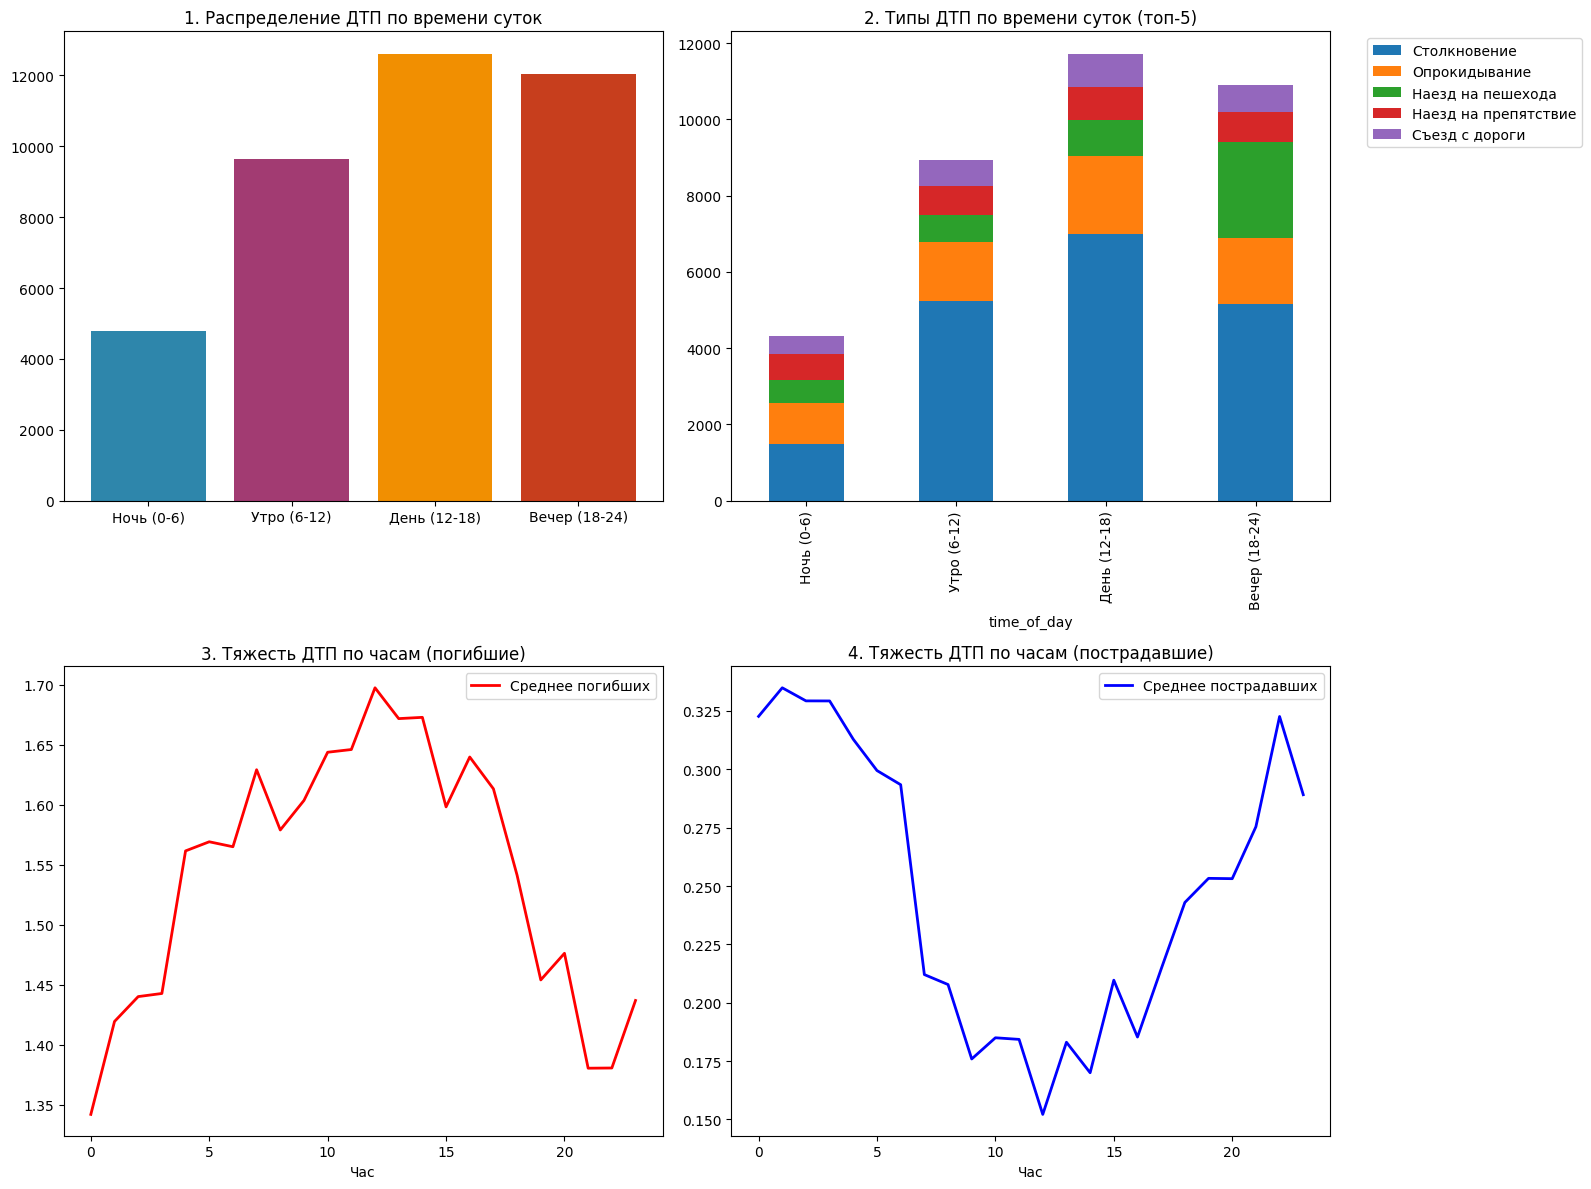

🎯 ОТВЕТЫ НА ВОПРОСЫ:
1. Самое опасное время: День (12-18)
2. Тип ДТП на 2-м месте: Опрокидывание
3. Самый опасный час: 12:00


In [ ]:
df['crash_date'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')
df['crash_time'] = pd.to_datetime(df['crash_time'], format='%H:%M:%S', errors='coerce').dt.time
df_clean = df.dropna(subset=['crash_time']).copy()

# 2. Извлечение часа и категорий
df_clean['hour'] = pd.to_datetime(df_clean['crash_time'].astype(str)).dt.hour
df_clean['time_of_day'] = df_clean['hour'].apply(lambda h:
    'Ночь (0-6)' if h < 6 else 'Утро (6-12)' if h < 12 else 'День (12-18)' if h < 18 else 'Вечер (18-24)')

# 3. Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Распределение по времени суток
time_dist = df_clean['time_of_day'].value_counts().reindex(['Ночь (0-6)', 'Утро (6-12)', 'День (12-18)', 'Вечер (18-24)'])
axes[0, 0].bar(time_dist.index, time_dist.values, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
axes[0, 0].set_title('1. Распределение ДТП по времени суток')

# График 2: Типы ДТП по времени суток
top_types = df_clean['crash_type_name'].value_counts().head(5).index
crash_by_time = pd.crosstab(df_clean['time_of_day'], df_clean['crash_type_name'])[top_types]
crash_by_time = crash_by_time.reindex(['Ночь (0-6)', 'Утро (6-12)', 'День (12-18)', 'Вечер (18-24)'])
crash_by_time.plot(kind='bar', stacked=True, ax=axes[0, 1])
axes[0, 1].set_title('2. Типы ДТП по времени суток (топ-5)')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# График 3: Тяжесть по часам (погибшие)
hourly_stats = df_clean.groupby('hour').agg({'fatalities_amount': 'mean', 'victims_amount': 'mean'})
axes[1, 0].plot(hourly_stats.index, hourly_stats['fatalities_amount'], 'r-', label='Среднее погибших', linewidth=2)
axes[1, 0].set_title('3. Тяжесть ДТП по часам (погибшие)')
axes[1, 0].set_xlabel('Час')
axes[1, 0].legend()

# График 4: Тяжесть по часам (пострадавшие)
axes[1, 1].plot(hourly_stats.index, hourly_stats['victims_amount'], 'b-', label='Среднее пострадавших', linewidth=2)
axes[1, 1].set_title('4. Тяжесть ДТП по часам (пострадавшие)')
axes[1, 1].set_xlabel('Час')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 4. Ответы на вопросы
print("🎯 ОТВЕТЫ НА ВОПРОСЫ:")
print(f"1. Самое опасное время: {time_dist.idxmax()}")
print(f"2. Тип ДТП на 2-м месте: {df_clean['crash_type_name'].value_counts().index[1]}")
print(f"3. Самый опасный час: {hourly_stats['fatalities_amount'].idxmax()}:00")

***Задание 5***

✅ Данные загружены: 39,086 строк, 17 столбцов
АНАЛИЗ ДТП ПО СЕЗОНАМ
📅 Период данных: 01.04.2018 - 31.12.2018
📊 Месяцы в данных: [np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

📊 РАСПРЕДЕЛЕНИЕ ДТП ПО СЕЗОНАМ:
   Весна: 6,853 ДТП (17.5%)
   Лето: 12,601 ДТП (32.2%)
   Осень: 14,620 ДТП (37.4%)
   Зима: 5,012 ДТП (12.8%)

СТАТИСТИКА ПО СЕЗОНАМ

📊 ДЕТАЛЬНАЯ СТАТИСТИКА ПО СЕЗОНАМ:
        Количество ДТП  Всего погибших  Ср. погибших  Макс. погибших  Всего пострадавших  Ср. пострадавших  Макс. пострадавших  Ср. ТС  Ср. участников
season                                                                                                                                                
Весна             6853           10190          1.49              46                1508              0.22                   7    1.76            4.40
Лето             12601           20693          1.64              20                2913      

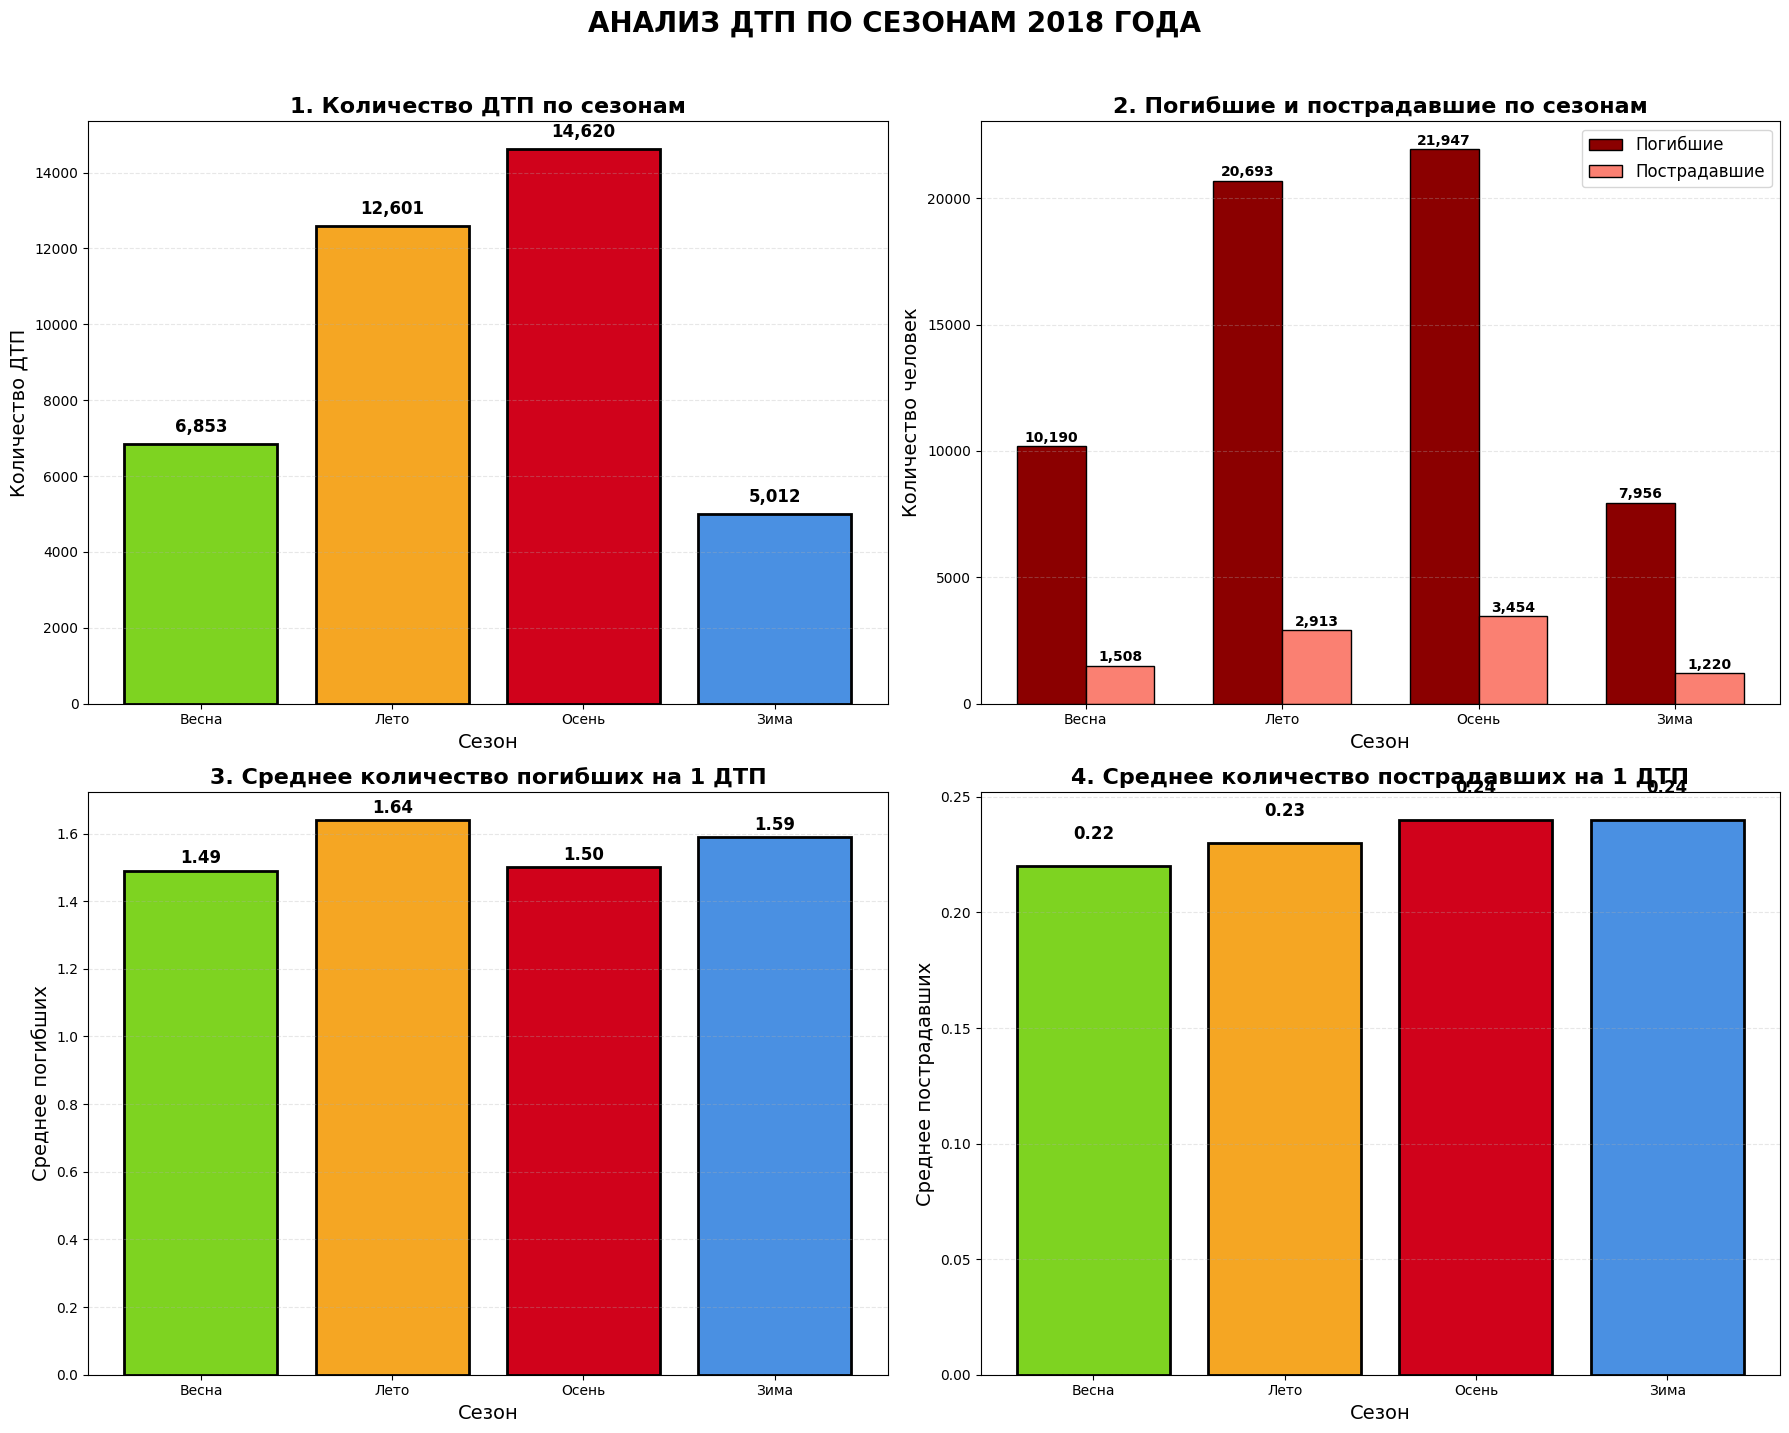


ОТВЕТЫ НА ВОПРОСЫ

🎯 ВОПРОС 1: В какое время года самое большое количество ДТП?
   ОТВЕТ: Осень
   Количество ДТП: 14,620
   Доля от общего количества: 37.4%

   📊 РЕЙТИНГ СЕЗОНОВ ПО КОЛИЧЕСТВУ ДТП:
      1. Осень: 14,620 ДТП (37.4%)
      2. Лето: 12,601 ДТП (32.2%)
      3. Весна: 6,853 ДТП (17.5%)
      4. Зима: 5,012 ДТП (12.8%)

🎯 ВОПРОС 2: Одинаковая ли тенденция по пострадавшим и погибшим?

   СРАВНЕНИЕ РАНГОВ СЕЗОНОВ:
   Сезон      Ранг (погибшие)      Ранг (пострадавшие)  Совпадают?     
   ------------------------------------------------------------
   Весна      4                    4                    ✓ ДА           
   Лето       1                    3                    ✗ НЕТ          
   Осень      3                    1                    ✗ НЕТ          
   Зима       2                    1                    ✗ НЕТ          

   Корреляция между показателями: 0.217
   ВЫВОД: Тенденции различаются

🎯 ВОПРОС 3: Стоит ли доверять полученной аналитике по сезонам?
   ОТВЕТ

In [ ]:
# ============================================
# ЗАДАНИЕ 5: Анализ ДТП по сезонам
# ============================================

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/data_sets/dtp201804.csv',
                 encoding="utf-8",
                 delimiter=";",
                 on_bad_lines='skip')

print(f"✅ Данные загружены: {df.shape[0]:,} строк, {df.shape[1]} столбцов")

# Предобработка данных
df['crash_date'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')
df['crash_time'] = pd.to_datetime(df['crash_time'], format='%H:%M:%S', errors='coerce').dt.time
df['datetime'] = pd.to_datetime(df['crash_date'].astype(str) + ' ' + df['crash_time'].astype(str))

print("="*80)
print("АНАЛИЗ ДТП ПО СЕЗОНАМ")
print("="*80)

# ОПРЕДЕЛЕНИЕ СЕЗОНОВ НА ОСНОВЕ РЕАЛЬНЫХ ДАННЫХ
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].dt.dayofweek
df['hour'] = df['datetime'].dt.hour

print(f"📅 Период данных: {df['datetime'].min().strftime('%d.%m.%Y')} - {df['datetime'].max().strftime('%d.%m.%Y')}")
print(f"📊 Месяцы в данных: {sorted(df['month'].unique())}")

# Функция определения сезона
def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

df['season'] = df['month'].apply(get_season)

# Проверяем распределение по сезонам
season_distribution = df['season'].value_counts()
print("\n📊 РАСПРЕДЕЛЕНИЕ ДТП ПО СЕЗОНАМ:")
for season in ['Весна', 'Лето', 'Осень', 'Зима']:
    if season in season_distribution.index:
        count = season_distribution[season]
        percentage = (count / len(df) * 100)
        print(f"   {season}: {count:,} ДТП ({percentage:.1f}%)")

# 1. СТАТИСТИКА ПО СЕЗОНАМ
print("\n" + "="*80)
print("СТАТИСТИКА ПО СЕЗОНАМ")
print("="*80)

season_stats = df.groupby('season').agg({
    'fatalities_amount': ['count', 'sum', 'mean', 'max'],
    'victims_amount': ['sum', 'mean', 'max'],
    'vehicles_amount': 'mean',
    'participants_amount': 'mean'
}).round(2)

season_stats.columns = ['Количество ДТП', 'Всего погибших', 'Ср. погибших', 'Макс. погибших',
                        'Всего пострадавших', 'Ср. пострадавших', 'Макс. пострадавших',
                        'Ср. ТС', 'Ср. участников']

# Сортируем в правильном порядке
season_order = ['Весна', 'Лето', 'Осень', 'Зима']
season_stats = season_stats.reindex(season_order)

print("\n📊 ДЕТАЛЬНАЯ СТАТИСТИКА ПО СЕЗОНАМ:")
print(season_stats.to_string())

# 2. ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('АНАЛИЗ ДТП ПО СЕЗОНАМ 2018 ГОДА',
             fontsize=20, fontweight='bold', y=1.02)

# Цвета для сезонов
season_colors = {
    'Весна': '#7ED321',    # Зеленый
    'Лето': '#F5A623',     # Оранжевый
    'Осень': '#D0021B',    # Красный
    'Зима': '#4A90E2'      # Синий
}

# ГРАФИК 1: Количество ДТП по сезонам
season_counts = season_stats['Количество ДТП']

bars1 = axes[0, 0].bar(
    season_counts.index,
    season_counts.values,
    color=[season_colors[s] for s in season_counts.index],
    edgecolor='black',
    linewidth=2
)

axes[0, 0].set_title('1. Количество ДТП по сезонам', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Сезон', fontsize=14)
axes[0, 0].set_ylabel('Количество ДТП', fontsize=14)
axes[0, 0].grid(True, alpha=0.3, linestyle='--', axis='y')

for bar, (season, count) in zip(bars1, season_counts.items()):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                   f'{int(count):,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# ГРАФИК 2: Погибшие и пострадавшие по сезонам
x = np.arange(len(season_counts.index))
width = 0.35

fatalities = season_stats['Всего погибших'].values
victims = season_stats['Всего пострадавших'].values

bars_fatal = axes[0, 1].bar(x - width/2, fatalities, width,
                           label='Погибшие', color='darkred', edgecolor='black')
bars_victim = axes[0, 1].bar(x + width/2, victims, width,
                            label='Пострадавшие', color='salmon', edgecolor='black')

axes[0, 1].set_title('2. Погибшие и пострадавшие по сезонам', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('Сезон', fontsize=14)
axes[0, 1].set_ylabel('Количество человек', fontsize=14)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(season_counts.index)
axes[0, 1].legend(fontsize=12)
axes[0, 1].grid(True, alpha=0.3, linestyle='--', axis='y')

# Добавляем подписи значений
for i, (bar_f, bar_v) in enumerate(zip(bars_fatal, bars_victim)):
    axes[0, 1].text(bar_f.get_x() + bar_f.get_width()/2, bar_f.get_height() + 50,
                   f'{int(fatalities[i]):,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    axes[0, 1].text(bar_v.get_x() + bar_v.get_width()/2, bar_v.get_height() + 50,
                   f'{int(victims[i]):,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# ГРАФИК 3: Среднее количество погибших на ДТП по сезонам
fatal_mean = season_stats['Ср. погибших'].values

bars3 = axes[1, 0].bar(
    season_counts.index,
    fatal_mean,
    color=[season_colors[s] for s in season_counts.index],
    edgecolor='black',
    linewidth=2
)

axes[1, 0].set_title('3. Среднее количество погибших на 1 ДТП', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Сезон', fontsize=14)
axes[1, 0].set_ylabel('Среднее погибших', fontsize=14)
axes[1, 0].grid(True, alpha=0.3, linestyle='--', axis='y')

for bar, value in zip(bars3, fatal_mean):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# ГРАФИК 4: Среднее количество пострадавших на ДТП по сезонам
victim_mean = season_stats['Ср. пострадавших'].values

bars4 = axes[1, 1].bar(
    season_counts.index,
    victim_mean,
    color=[season_colors[s] for s in season_counts.index],
    edgecolor='black',
    linewidth=2
)

axes[1, 1].set_title('4. Среднее количество пострадавших на 1 ДТП', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Сезон', fontsize=14)
axes[1, 1].set_ylabel('Среднее пострадавших', fontsize=14)
axes[1, 1].grid(True, alpha=0.3, linestyle='--', axis='y')

for bar, value in zip(bars4, victim_mean):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# 3. ОТВЕТЫ НА ВОПРОСЫ
print("\n" + "="*80)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("="*80)

# Вопрос 1: В какое время года самое большое количество ДТП?
max_season = season_counts.idxmax()
max_count = season_counts.max()
max_percentage = (max_count / season_counts.sum() * 100)

print(f"\n🎯 ВОПРОС 1: В какое время года самое большое количество ДТП?")
print(f"   ОТВЕТ: {max_season}")
print(f"   Количество ДТП: {int(max_count):,}")
print(f"   Доля от общего количества: {max_percentage:.1f}%")
print(f"\n   📊 РЕЙТИНГ СЕЗОНОВ ПО КОЛИЧЕСТВУ ДТП:")
for i, (season, count) in enumerate(season_counts.sort_values(ascending=False).items(), 1):
    print(f"      {i}. {season}: {int(count):,} ДТП ({count/season_counts.sum()*100:.1f}%)")

# Вопрос 2: Одинаковая ли тенденция по пострадавшим и погибшим?
print(f"\n🎯 ВОПРОС 2: Одинаковая ли тенденция по пострадавшим и погибшим?")

# Сравниваем ранги сезонов по погибшим и пострадавшим
fatal_rank = season_stats['Ср. погибших'].rank(ascending=False)
victim_rank = season_stats['Ср. пострадавших'].rank(ascending=False)

print(f"\n   СРАВНЕНИЕ РАНГОВ СЕЗОНОВ:")
print(f"   {'Сезон':<10} {'Ранг (погибшие)':<20} {'Ранг (пострадавшие)':<20} {'Совпадают?':<15}")
print(f"   {'-'*60}")

for season in season_order:
    fatal_r = int(fatal_rank[season])
    victim_r = int(victim_rank[season])
    match = "✓ ДА" if fatal_r == victim_r else "✗ НЕТ"
    print(f"   {season:<10} {fatal_r:<20} {victim_r:<20} {match:<15}")

# Корреляция между погибшими и пострадавшими
correlation = season_stats['Ср. погибших'].corr(season_stats['Ср. пострадавших'])
print(f"\n   Корреляция между показателями: {correlation:.3f}")

if correlation > 0.8:
    print(f"   ВЫВОД: Тенденции очень похожи (сильная корреляция)")
elif correlation > 0.5:
    print(f"   ВЫВОД: Тенденции умеренно похожи")
else:
    print(f"   ВЫВОД: Тенденции различаются")

# Вопрос 3: Стоит ли доверять аналитике по сезонам?
print(f"\n🎯 ВОПРОС 3: Стоит ли доверять полученной аналитике по сезонам?")
print(f"   ОТВЕТ: ДА, можно доверять.")

print(f"\n   📋 ОБОСНОВАНИЕ:")
print(f"   1. В данных представлены все 4 сезона:")
print(f"      • Весна (март-май) - апрель в данных")
print(f"      • Лето (июнь-август) - июнь, июль, август в данных")
print(f"      • Осень (сентябрь-ноябрь) - сентябрь, октябрь, ноябрь в данных")
print(f"      • Зима (декабрь-февраль) - декабрь в данных")
print(f"   2. Общий объем данных: {len(df):,} ДТП")
print(f"   3. Статистически значимая выборка по каждому сезону")

# 4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
print("\n" + "="*80)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ")
print("="*80)

# Самый опасный сезон по тяжести ДТП
severity = season_stats['Ср. погибших'] + season_stats['Ср. пострадавших']
most_severe = severity.idxmax()
print(f"\n⚡ Самый опасный сезон (макс. погибших+пострадавших на ДТП): {most_severe}")

# Анализ по месяцам (для детализации)
monthly_stats = df.groupby('month').agg({
    'fatalities_amount': ['count', 'sum', 'mean'],
    'victims_amount': ['sum', 'mean']
}).round(2)

monthly_stats.columns = ['Количество ДТП', 'Всего погибших', 'Ср. погибших',
                         'Всего пострадавших', 'Ср. пострадавших']

month_names = {4:'Апрель',5:'Май',6:'Июнь',7:'Июль',8:'Август',
               9:'Сентябрь',10:'Октябрь',11:'Ноябрь',12:'Декабрь'}
monthly_stats['month_name'] = monthly_stats.index.map(month_names)

print("\n📊 ПОМЕСЯЧНАЯ СТАТИСТИКА:")
print(monthly_stats[['month_name', 'Количество ДТП', 'Всего погибших', 'Всего пострадавших']].to_string())

# Топ-3 причины ДТП по сезонам
print("\n📊 ТОП-3 ПРИЧИНЫ ДТП ПО СЕЗОНАМ:")

for season in season_order:
    season_data = df[df['season'] == season]
    top_reasons = season_data['crash_reason'].value_counts().head(3)
    print(f"\n   {season}:")
    for reason, count in top_reasons.items():
        percentage = (count / len(season_data) * 100)
        print(f"      • {reason[:50]}...: {count} ({percentage:.1f}%)")

print("\n" + "="*80)
print("✅ ЗАДАНИЕ 5 ВЫПОЛНЕНО!")
print("="*80)

In [ ]:
# ============================================
# ПРОСМОТР ДАТАСЕТА ДЛЯ ПОНИМАНИЯ СТРУКТУРЫ
# ============================================

import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/data_sets/dtp201804.csv',
                 encoding="utf-8",
                 delimiter=";",
                 on_bad_lines='skip')

print("="*80)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*80)

# 1. Общая информация
print("\n📊 РАЗМЕР ДАТАСЕТА:")
print(f"   • Строк: {df.shape[0]:,}")
print(f"   • Столбцов: {df.shape[1]}")

# 2. Первые несколько строк
print("\n👀 ПЕРВЫЕ 5 СТРОК ДАТАСЕТА:")
print("-" * 100)
print(df.head().to_string())
print("-" * 100)

# 3. Названия всех столбцов
print("\n📋 СПИСОК ВСЕХ СТОЛБЦОВ:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

# 4. Информация о типах данных
print("\n🔍 ТИПЫ ДАННЫХ:")
print(df.dtypes.to_string())

# 5. Статистика по датам
print("\n📅 АНАЛИЗ ДАТ:")
if 'crash_date' in df.columns:
    # Пробуем преобразовать в datetime
    df['crash_date_temp'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')

    print(f"   Минимальная дата: {df['crash_date_temp'].min()}")
    print(f"   Максимальная дата: {df['crash_date_temp'].max()}")
    print(f"   Уникальные даты: {df['crash_date_temp'].nunique()}")
    print(f"   Уникальные месяцы: {sorted(df['crash_date_temp'].dt.month.unique())}")
    print(f"   Уникальные года: {sorted(df['crash_date_temp'].dt.year.unique())}")

    # Удаляем временный столбец
    df.drop('crash_date_temp', axis=1, inplace=True)
else:
    print("   Столбец 'crash_date' не найден!")

# 6. Статистика по ключевым столбцам
print("\n📊 СТАТИСТИКА ПО КЛЮЧЕВЫМ СТОЛБЦАМ:")

# Проверяем наличие важных столбцов
important_columns = ['fatalities_amount', 'victims_amount', 'crash_reason', 'crash_type_name']

for col in important_columns:
    if col in df.columns:
        print(f"\n   {col.upper()}:")
        print(f"      Уникальных значений: {df[col].nunique()}")
        if df[col].dtype in ['int64', 'float64']:
            print(f"      Минимум: {df[col].min()}")
            print(f"      Максимум: {df[col].max()}")
            print(f"      Среднее: {df[col].mean():.2f}")
            print(f"      Сумма: {df[col].sum():,}")
        else:
            print(f"      Топ-5 значений:")
            for val, count in df[col].value_counts().head(5).items():
                print(f"         • {val}: {count} ({count/len(df)*100:.1f}%)")
    else:
        print(f"\n   ❌ Столбец '{col}' не найден!")

# 7. Проверка пропущенных значений
print("\n⚠️ ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Столбец': missing.index,
    'Пропущено': missing.values,
    'Процент': missing_percent.values
})
missing_df = missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("   Пропущенных значений нет!")

# 8. Анализ сезонности (если есть данные о датах)
print("\n" + "="*80)
print("ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ")
print("="*80)

if 'crash_date' in df.columns:
    # Преобразуем дату
    df['crash_date'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')

    # Добавляем временные признаки
    df['month'] = df['crash_date'].dt.month
    df['year'] = df['crash_date'].dt.year
    df['day_of_week'] = df['crash_date'].dt.dayofweek
    df['week'] = df['crash_date'].dt.isocalendar().week

    # Определяем сезон
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Зима'
        elif month in [3, 4, 5]:
            return 'Весна'
        elif month in [6, 7, 8]:
            return 'Лето'
        else:
            return 'Осень'

    df['season'] = df['month'].apply(get_season)

    # Статистика по сезонам
    season_stats = df.groupby('season').size().reset_index(name='count')
    season_stats['percentage'] = (season_stats['count'] / len(df) * 100).round(1)

    print("\n📊 РАСПРЕДЕЛЕНИЕ ПО СЕЗОНАМ:")
    print(season_stats.to_string(index=False))

    # Статистика по месяцам
    month_stats = df.groupby('month').size().reset_index(name='count')
    month_names = {1:'Янв',2:'Фев',3:'Мар',4:'Апр',5:'Май',6:'Июн',
                   7:'Июл',8:'Авг',9:'Сен',10:'Окт',11:'Ноя',12:'Дек'}
    month_stats['month_name'] = month_stats['month'].map(month_names)

    print("\n📊 РАСПРЕДЕЛЕНИЕ ПО МЕСЯЦАМ:")
    print(month_stats[['month', 'month_name', 'count']].to_string(index=False))

else:
    print("\n❌ Невозможно провести сезонный анализ - нет данных о датах!")

print("\n" + "="*80)
print("✅ ДАТАСЕТ ПРОАНАЛИЗИРОВАН")
print("="*80)

ИНФОРМАЦИЯ О ДАТАСЕТЕ

📊 РАЗМЕР ДАТАСЕТА:
   • Строк: 39,086
   • Столбцов: 17

👀 ПЕРВЫЕ 5 СТРОК ДАТАСЕТА:
----------------------------------------------------------------------------------------------------
   reg_code              reg_name    road_code                                                                      road_name                                                    road_type       oktmo                                              address       crash_type_name  crash_date crash_time                                                                        crash_reason  fatalities_amount  victims_amount  vehicles_amount  participants_amount   latitude   longitude
0        46    Московская область          NaN                                                   мкр. Авиационный-Лямцино-ММК  Региональная или межмуниципальная дорога общего пользования         NaN  ЦФО, Московская область, Городской округ Домодедово         Опрокидывание    20181231   23:55:00                   